### Transformata Hougha w przestrzeni ab - Domowe
Przestrzeń ρ,θ nie jest jedyną przestrzenią w której punkt odpowiada parametrom prostej. Np. można spróbować wykorzystać tradycyjne równanie prostej:

y=ax+b

W tej przestrzeni reprezentacją pęku prostych jest prosta. 

Zadanie: napisać funkcję, która jako argument przyjmuje obraz (binarny) oraz parametry:

- aMin - minimalna wartość parametru a
- aMax - maksymalna  wartość parametru a
- aSkok - skok parametru a
- bMin - minimalna wartość parametru b
- bMax  - maksymalna  wartość parametru b
- bSkok - skok parametru b
Jako wynik ma zwrócić macierz przestrzeni Hougha ab.

Uwagi:

- zadanie może wyglądać na skomplikowane ale tak naprawdę wymaga tylko starannego przemyślenia
- najważniejszy jest problem "adresowania" macierzy H. Można do tego wykorzystać dwa wektory A i B ze wszystkimi możliwymi wartościami jakie parametry a i b mogę przyjąć (w podanych zakresach z podanym skokiem). Wówczas indeksy tych wektorów będą współrzędnymi w macierzy H. Do stworzenia wektorów wykorzystaj funkcję _np.arange_
- na podstawie rozmiaru wektorów A i B (własność _shape_) należy stworzyć wyzerowaną macierz H (funkcja _np.zeros_) 
- dla każdego punktu krawędzi na obrazie należy:
    - używająć wektora A dla każdej z jego wartości a obliczyć odpowiednią wartość b - indeksy kolejnych wartości a (a_idx) będą jedną z współrzędnych macierzy H, natomiast drugą współrędną mozna uzyskać jako b_idx = np.argmin(abs(B - b)).
        - każde a_idx i b_idx wyznaczą punkt w macierzy H, który należy zinkrementować
- działanie funkcji należy przetestować na punktach generowanych w 'edytorku' z punktu "Transformacja Hougha dla małej liczby punktów". Proponowane parametry funkcji:
    - aMin: -5
    - aMax:  5
    - aSkok: 0.05 
    - bMin: -100
    - bMax:  100
    - bSkok: 1

Zastanów się w przypadku jakich prostych reprezentacja ab nie sprawdzi się.

In [40]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from skimage.transform import hough_line, hough_line_peaks

In [41]:
def Hough_trans_ab(img,aMin,aMax,aSkok,bMin,bMax,bSkok):
    A=np.arange(aMin,aMax,aSkok)
    B=np.arange(bMin,bMax,bSkok)
    H=np.zeros((A.shape[0],B.shape[0]))
    # bin_x, bin_y = binary.shape
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if (img[i,j]==1):
                for z in range(len(A)):
                    a_idx=z
                    b=j-A[z]*i
                    b_idx=np.argmin(abs(B-b))
                    H[a_idx,b_idx]+=1
    return H

def show_hough(h, image):
    # Generating figure 1
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    ax = axes.ravel()

    ax[0].imshow(image, 'gray')
    ax[0].set_title('Input image')
    ax[0].set_axis_off()

    ax[1].imshow(h, 'gray')
    ax[1].set_title('AB Hough transform')
    ax[1].set_xlabel('A')
    ax[1].set_ylabel('B')
    ax[1].axis('image')
    
    plt.tight_layout()
    plt.show()    

In [42]:
aMin=-5
aMax=5
aSkok=0.05
bMin=-100
bMax=100
bSkok=1

im1=np.zeros((100,100))
im1[40,25]=1
im2=np.zeros((100,100))
im2[20,25]=1
im2[60,90]=1
im3=np.zeros((100,100))
im3[20,20]=1
im3[40,40]=1
im3[60,60]=1
im4=np.zeros((100,100))
im4[5][10]=1
im4[15][30]=1
im4[20][40]=1
im4[30][15]=1
im5=np.zeros((100,100))
im5[0,50]=1
im5[0,60]=1
im5[0,70]=1
im6=np.zeros((100,100))
im6[5,50]=1
im6[5,60]=1
im6[5,70]=1
im7=np.zeros((100,100))
im7[90,50]=1
im7[90,60]=1
im7[90,70]=1
im8=np.zeros((100,100))
im8[99,50]=1
im8[99,60]=1
im8[99,70]=1
im9=np.zeros((100,100))
im9[5,50]=1
im9[15,50]=1
im9[25,50]=1


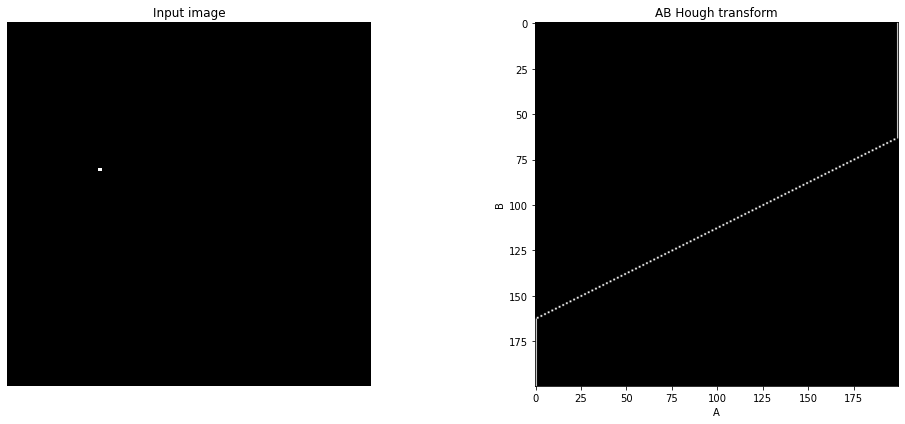

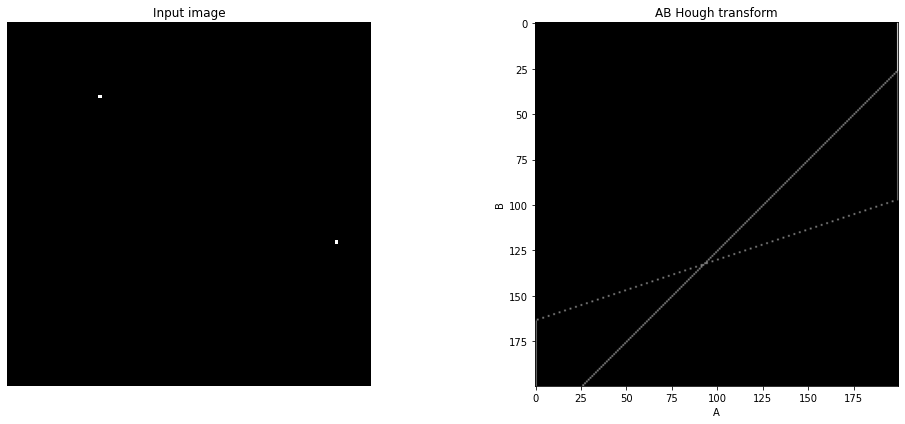

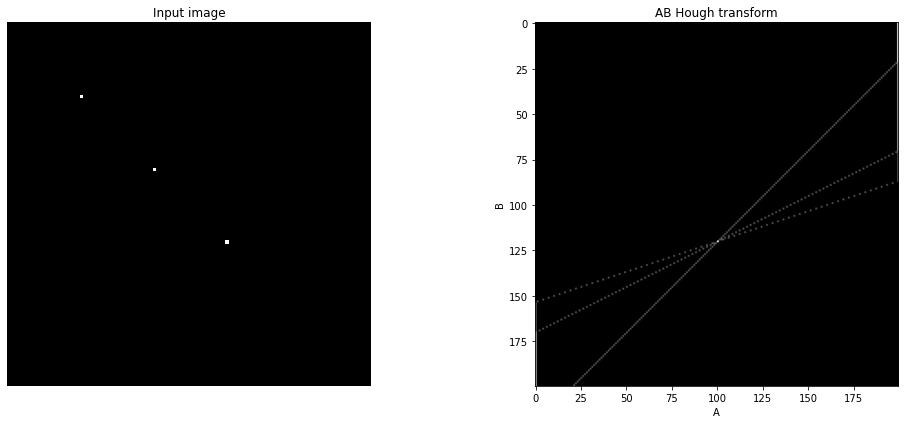

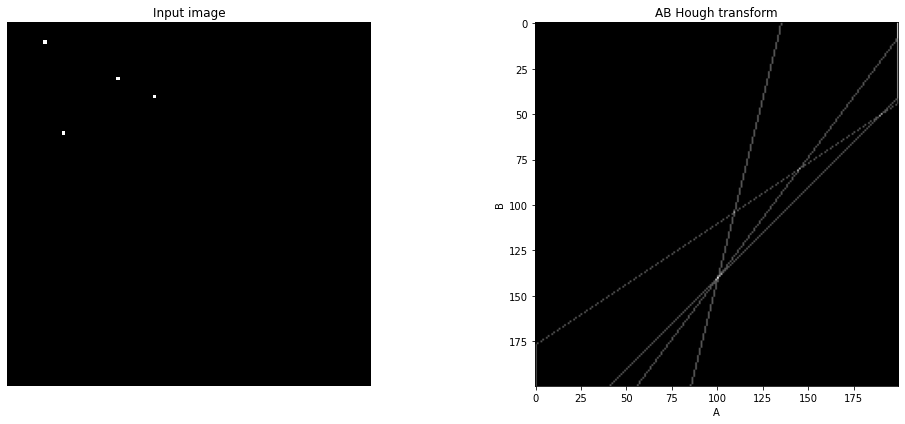

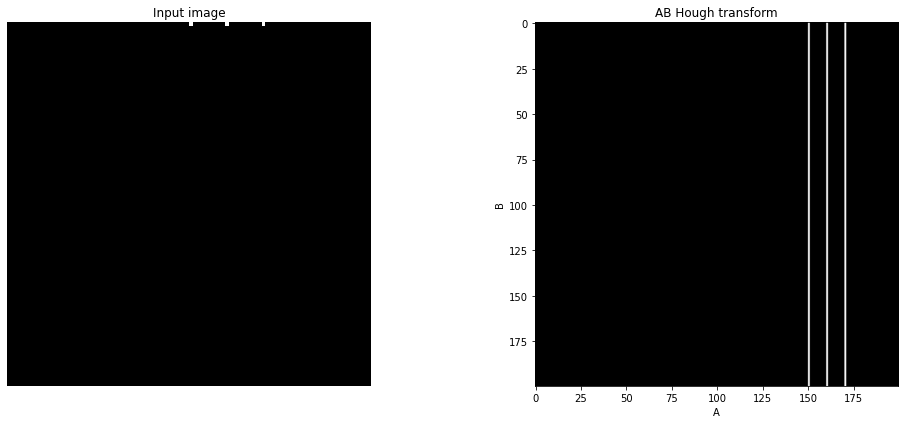

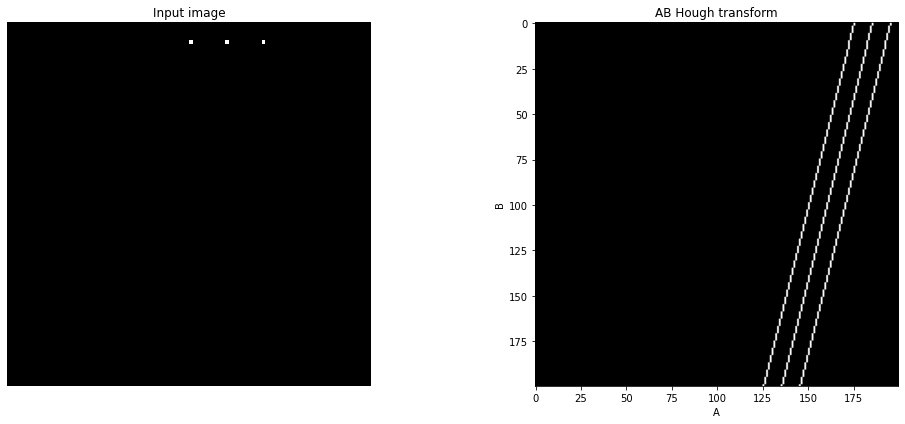

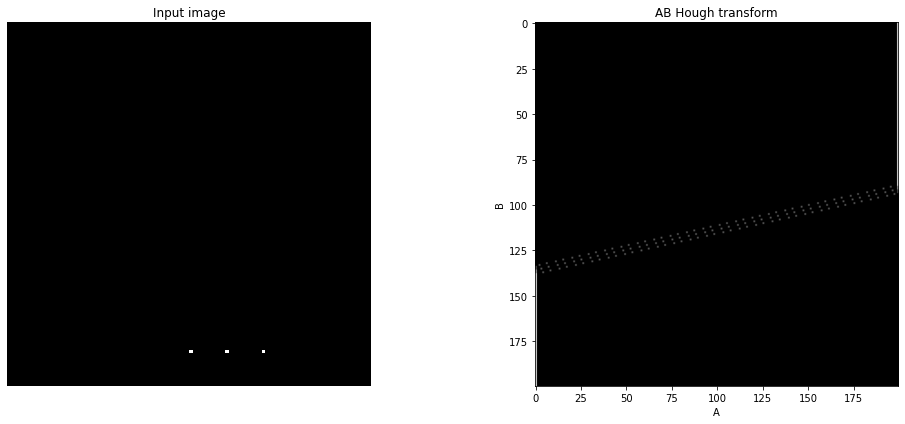

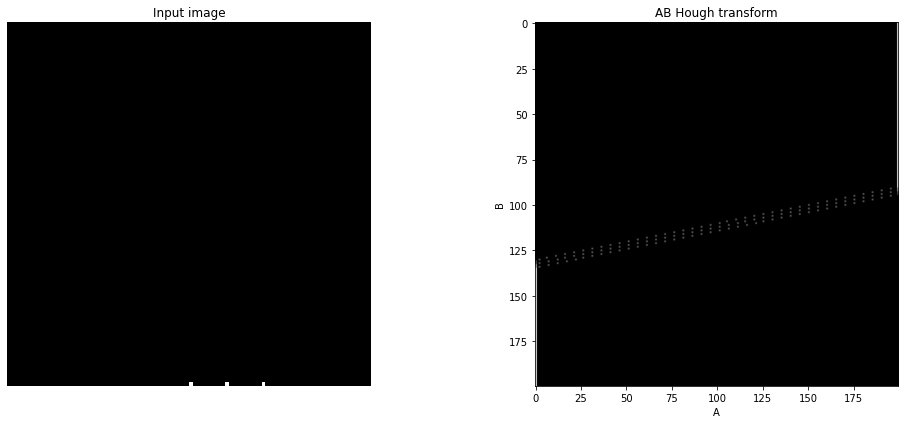

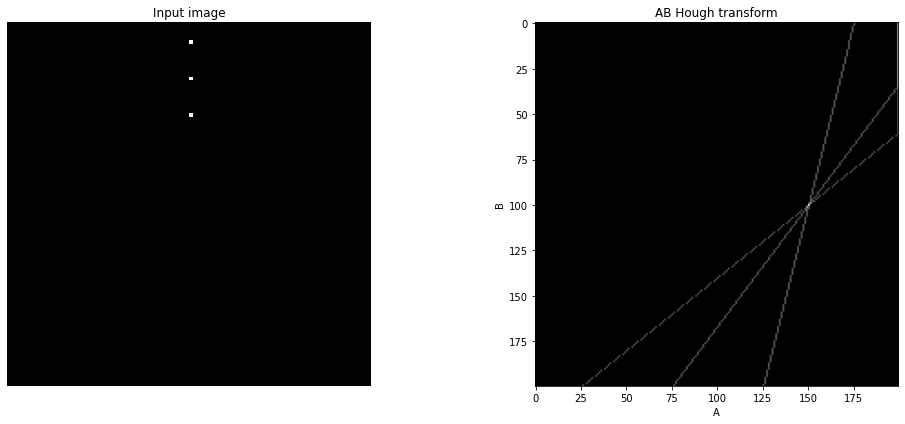

In [43]:
show_hough(Hough_trans_ab(im1,aMin,aMax,aSkok,bMin,bMax,bSkok),im1)
show_hough(Hough_trans_ab(im2,aMin,aMax,aSkok,bMin,bMax,bSkok),im2)
show_hough(Hough_trans_ab(im3,aMin,aMax,aSkok,bMin,bMax,bSkok),im3)
show_hough(Hough_trans_ab(im4,aMin,aMax,aSkok,bMin,bMax,bSkok),im4)
show_hough(Hough_trans_ab(im5,aMin,aMax,aSkok,bMin,bMax,bSkok),im5)
show_hough(Hough_trans_ab(im6,aMin,aMax,aSkok,bMin,bMax,bSkok),im6)
show_hough(Hough_trans_ab(im7,aMin,aMax,aSkok,bMin,bMax,bSkok),im7)
show_hough(Hough_trans_ab(im8,aMin,aMax,aSkok,bMin,bMax,bSkok),im8)
show_hough(Hough_trans_ab(im9,aMin,aMax,aSkok,bMin,bMax,bSkok),im9)

Nie ma takiego układu punktów który w przestrzenii Hough'a tworzyłby poziomą prostą.